# RF Dataset Overview

This notebook is the short entry point for the RF post-processing tutorials.

Use it to:
- open the latest NetCDF dataset for one experiment
- inspect the dataset summary
- plot the rover trajectory
- plot phase and amplitude heatmaps for the last `100` CSI cycle values

For focused walkthroughs, also open:
- `tutorial_rover_positions.ipynb`
- `tutorial_csi_per_position.ipynb`


In [1]:
# Optional: uncomment when this Jupyter kernel misses the plotting dependencies.
# import sys
# !{sys.executable} -m pip install matplotlib numpy requests xarray pyyaml


In [2]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
for candidate_dir in (
    NOTEBOOK_DIR,
    NOTEBOOK_DIR / "tutorials",
    NOTEBOOK_DIR / "processing" / "tutorials",
):
    if (candidate_dir / "csi_plot_utils.py").exists():
        NOTEBOOK_DIR = candidate_dir.resolve()
        break
else:
    raise ImportError(f"Could not locate csi_plot_utils.py from {Path.cwd().resolve()}")

UTILS_PATH = NOTEBOOK_DIR / "csi_plot_utils.py"
PROCESSING_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = PROCESSING_DIR.parent
spec = importlib.util.spec_from_file_location("csi_plot_utils", UTILS_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load utility module from {UTILS_PATH}")
csi = importlib.util.module_from_spec(spec)
sys.modules["csi_plot_utils"] = csi
spec.loader.exec_module(csi)


In [3]:
EXPERIMENT_ID = "EXP003"
DATASET_PATH = None  # Set this to a specific .nc file when you do not want the newest match.
HEATMAP_MAX_CYCLE_VALUES = csi.DEFAULT_HEATMAP_MAX_CYCLE_VALUES


In [4]:
ds, dataset_path = csi.open_dataset(experiment_id=EXPERIMENT_ID, dataset_path=DATASET_PATH)
antenna_positions = csi.load_antenna_positions()

print(f"Loaded dataset: {dataset_path}")
print(f"Loaded {len(antenna_positions)} antenna positions from: {csi.POSITIONS_URL}")
csi.print_dataset_overview(ds)
csi.print_experiment_overview(ds, EXPERIMENT_ID)


Loaded dataset: /home/hxiong/project/ELLIIIT-dataset-26/results/csi_EXP003__EXP005__EXP006__EXP007__EXP008__EXP009__EXP010__EXP011__EXP012.nc
Loaded 140 antenna positions from: https://raw.githubusercontent.com/techtile-by-dramco/techtile-description/refs/heads/main/geometry/techtile_antenna_locations.yml
Experiments: ['EXP003', 'EXP005', 'EXP006', 'EXP007', 'EXP008', 'EXP009', 'EXP010', 'EXP011', 'EXP012']
Dataset shape: experiment_id=9, cycle_id=1355, hostname=42
Cycle ID range: 1 .. 1356
Last measurement timestamp: 2026-04-04T07:54:35+02:00 (source file mtime)
EXP003: cycles_with_csi=529, valid_positions=529, first_csi_cycle=1, last_csi_cycle=529


## Rover Trajectory

The plot below uses the filtered rover coordinates stored in the xarray. Invalid, missing, and duplicate consecutive positions were already removed during extraction.


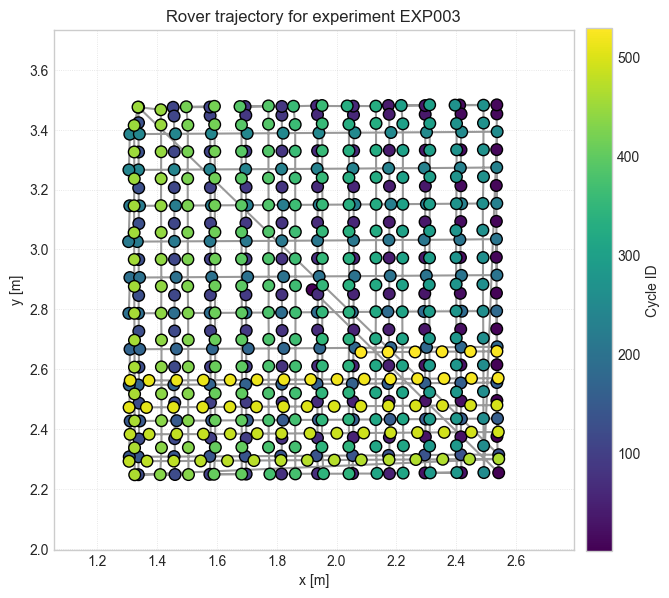

In [5]:
csi.plot_trajectory(ds, EXPERIMENT_ID)
plt.show()


## CSI Heatmaps

These overview plots show the last `HEATMAP_MAX_CYCLE_VALUES` cycle values for the selected experiment. Use the two focused tutorial notebooks when you want to inspect rover positions or CSI for one specific position in more detail.


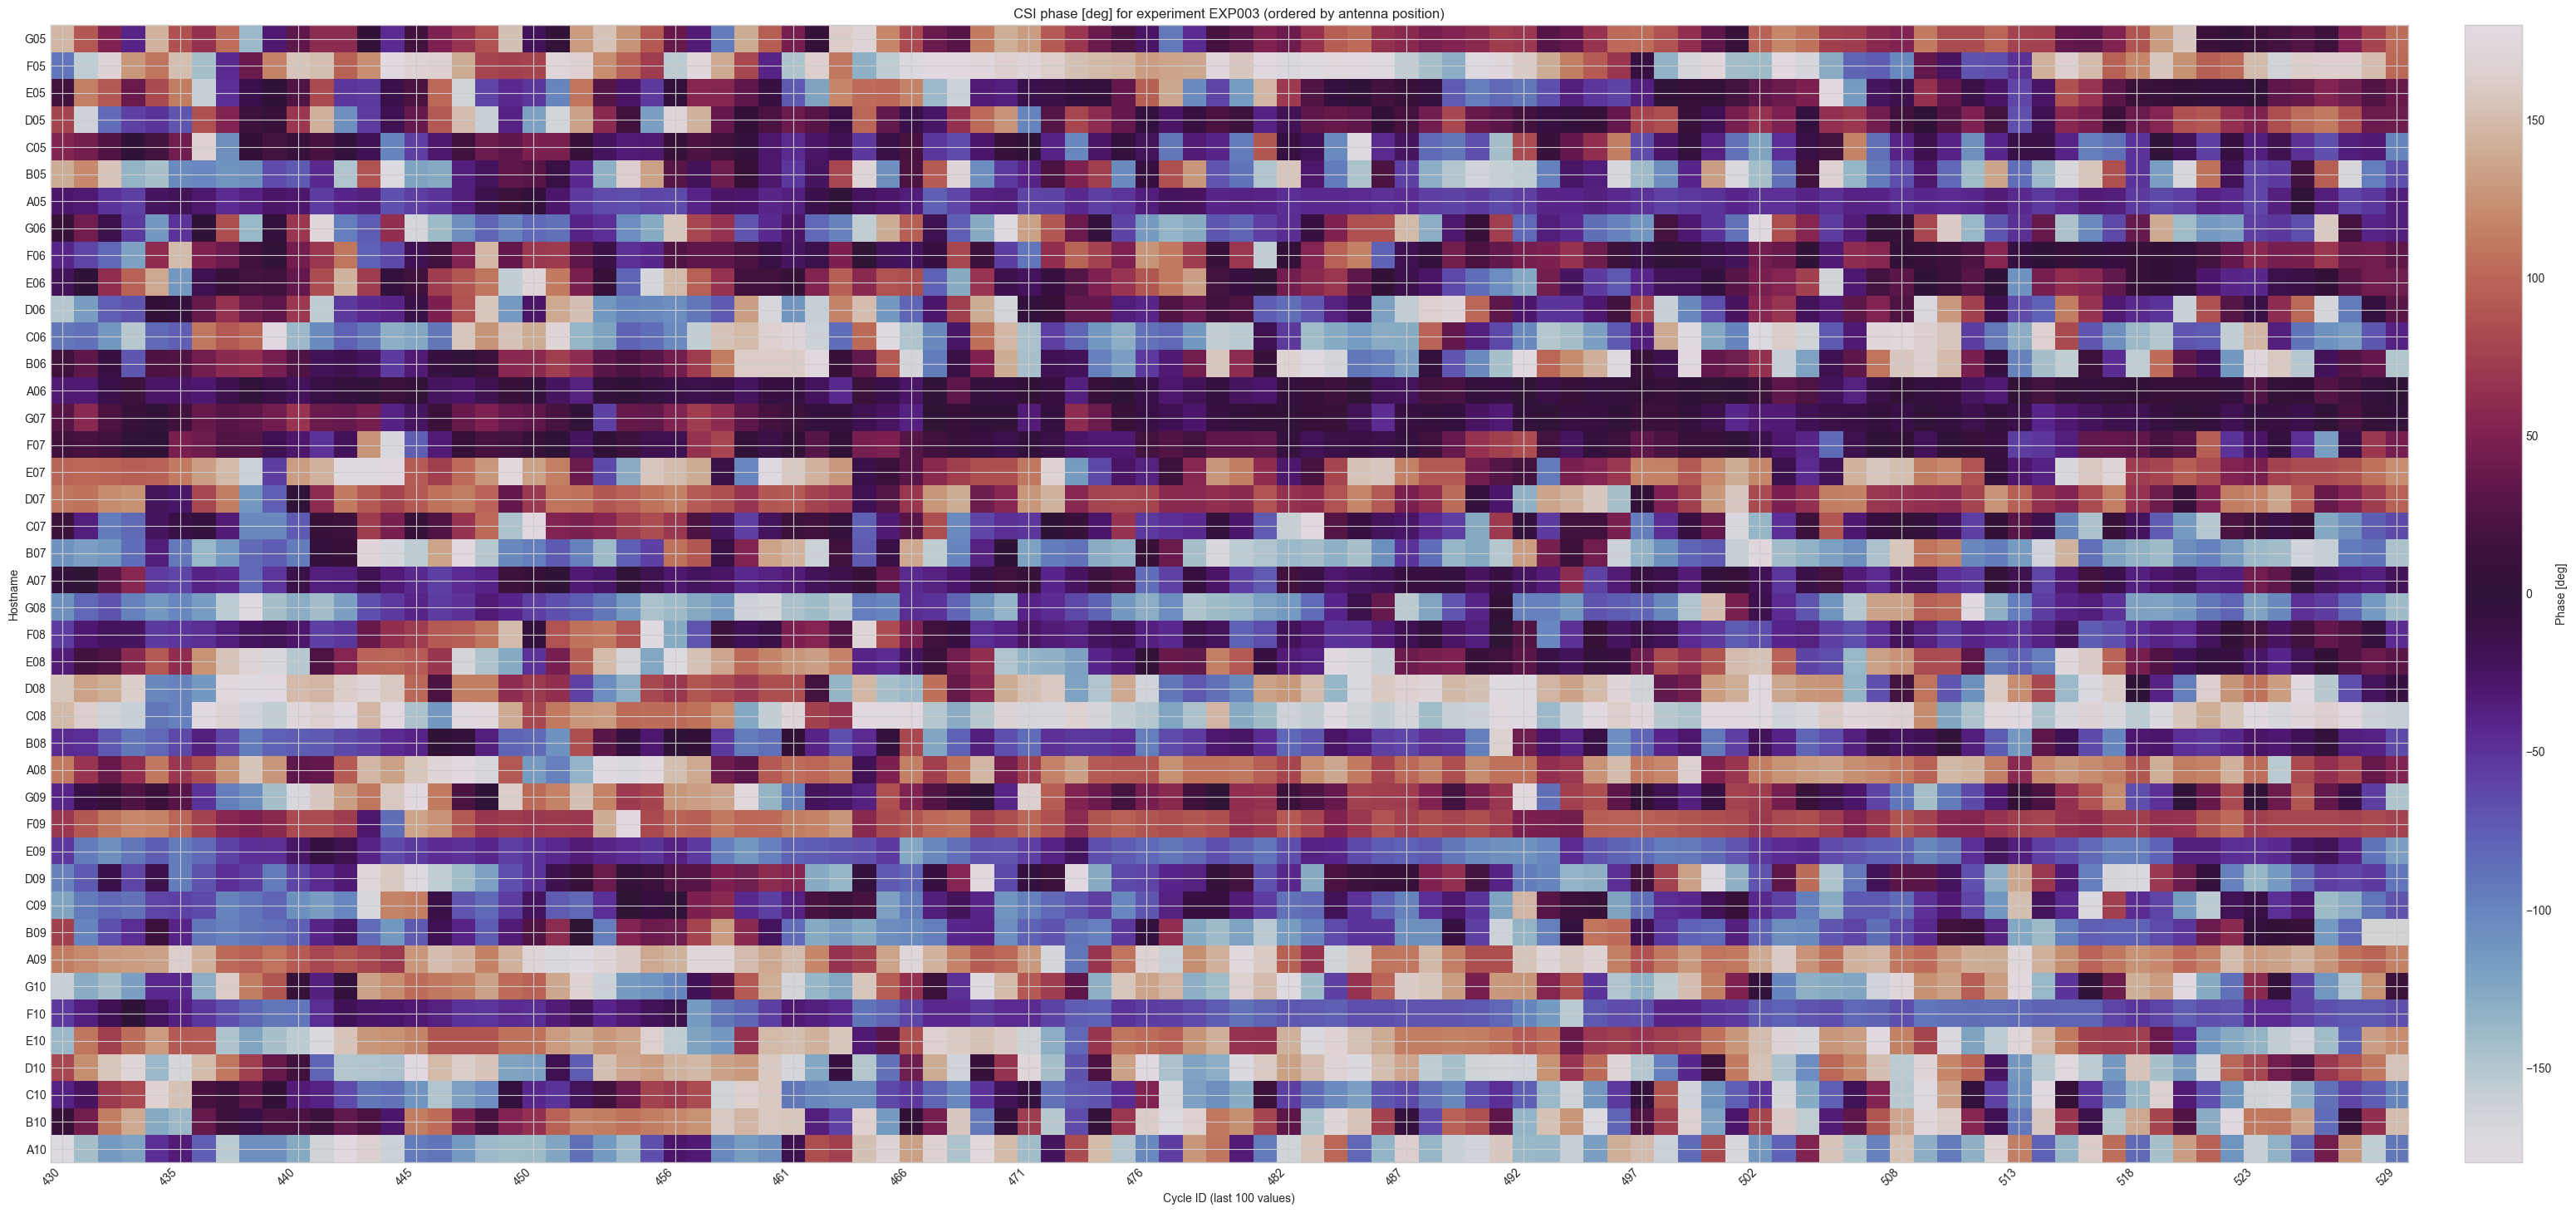

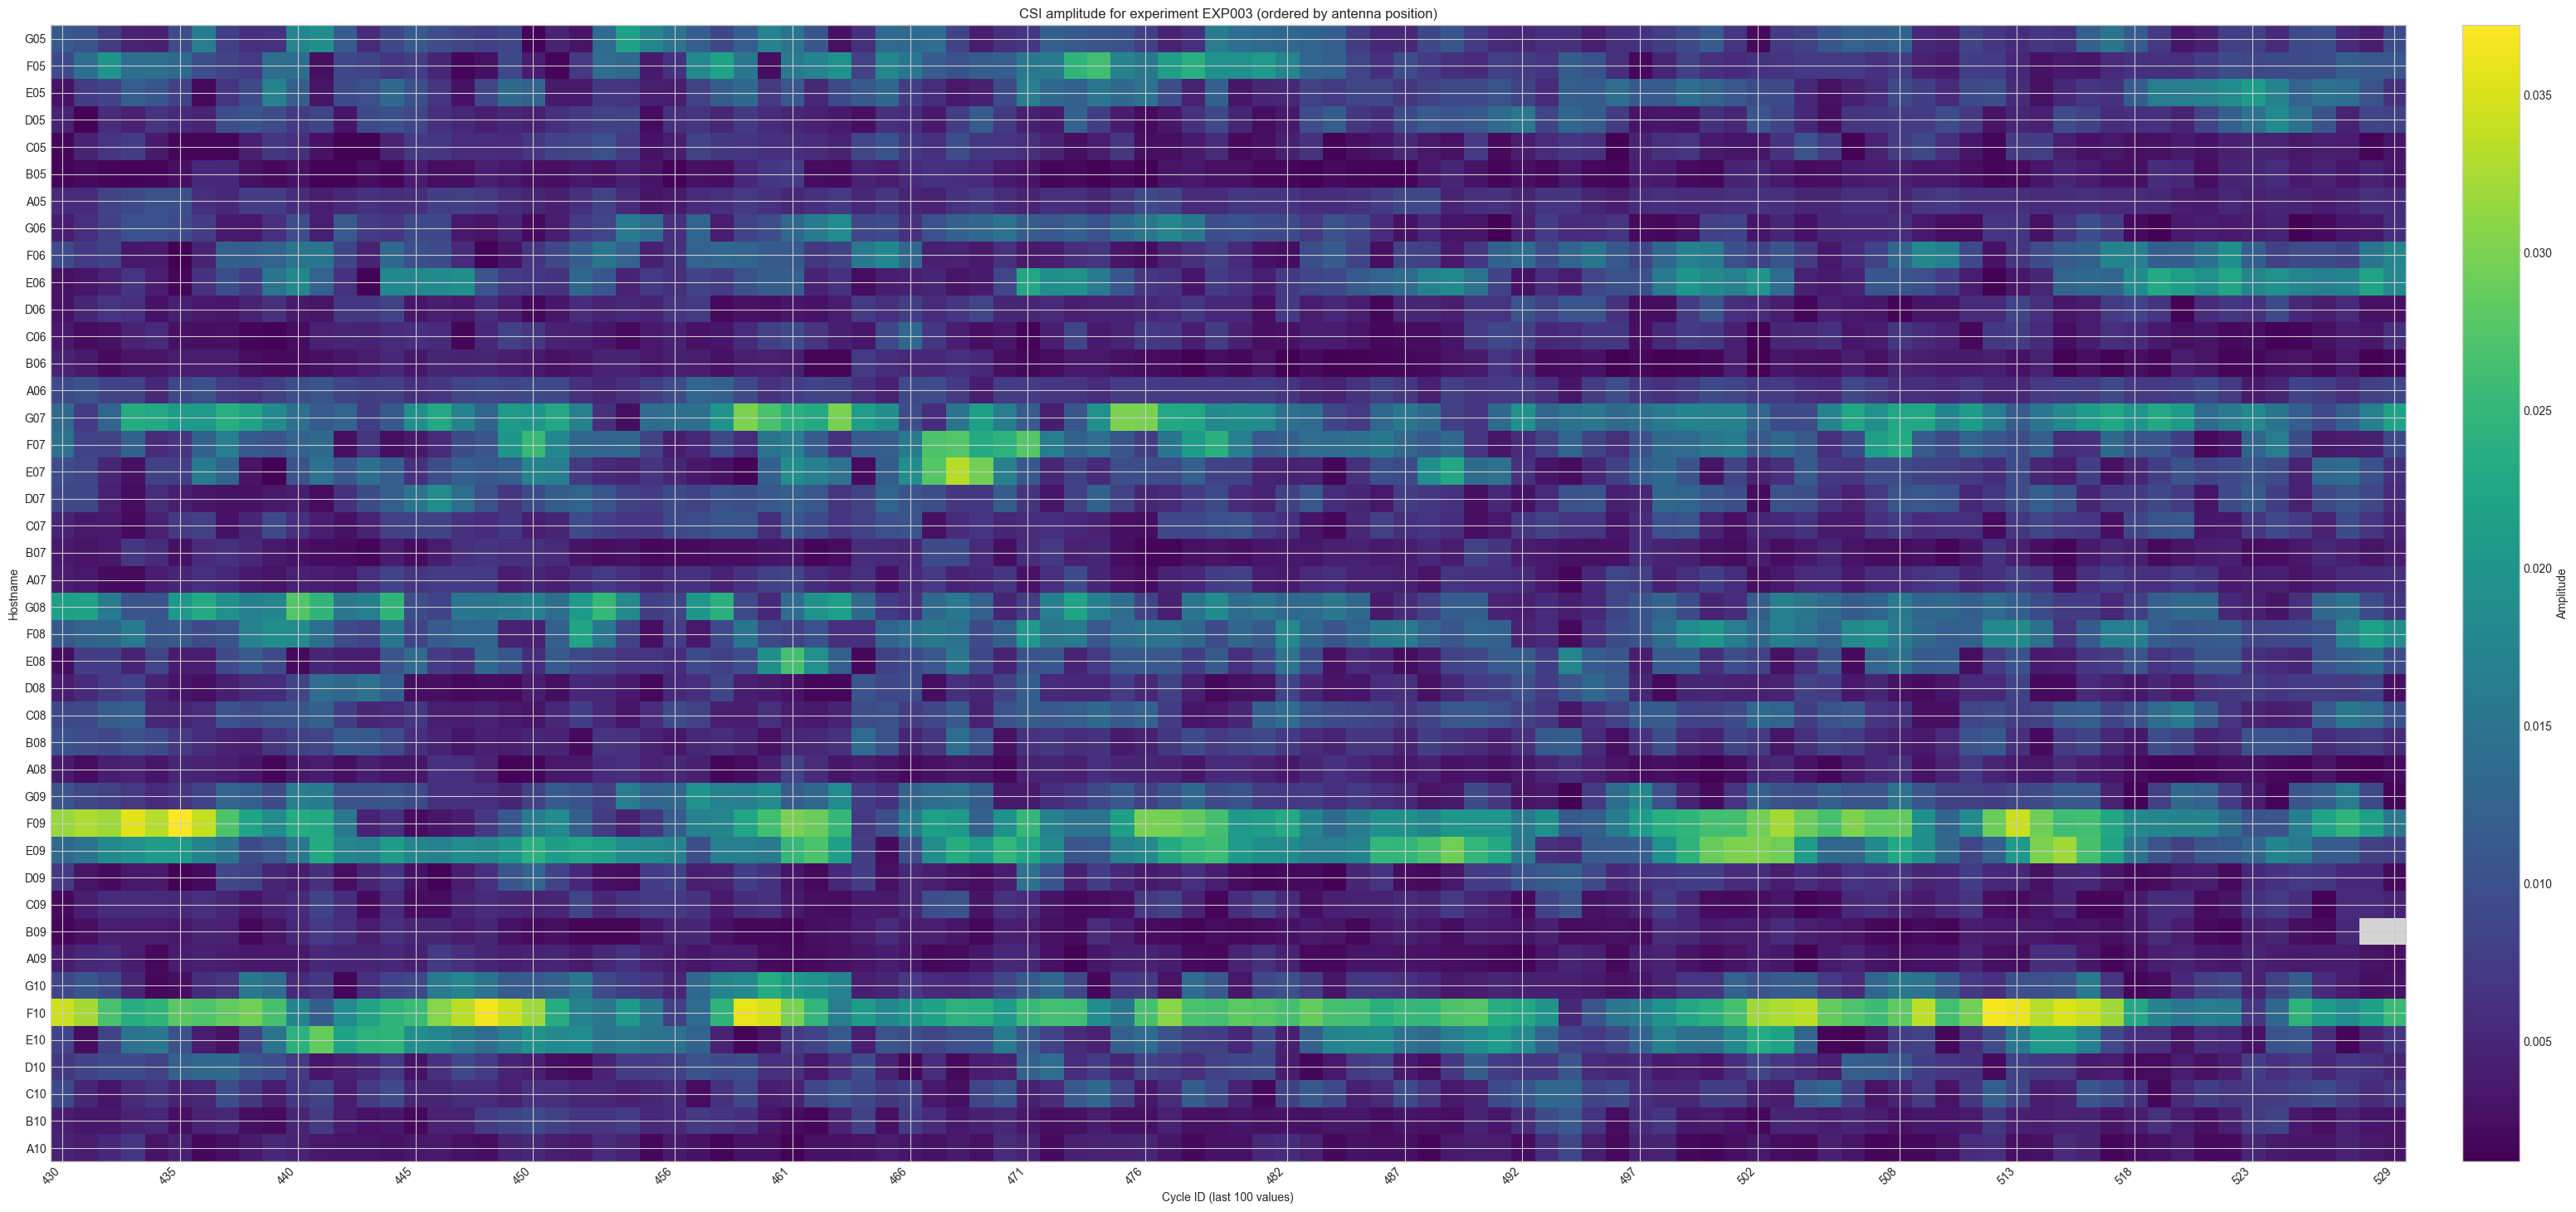

In [6]:
csi.plot_phase_heatmap(
    ds,
    EXPERIMENT_ID,
    antenna_positions=antenna_positions,
    max_cycle_values=HEATMAP_MAX_CYCLE_VALUES,
)
plt.show()

csi.plot_amplitude_heatmap(
    ds,
    EXPERIMENT_ID,
    antenna_positions=antenna_positions,
    max_cycle_values=HEATMAP_MAX_CYCLE_VALUES,
)
plt.show()
